# Ejercicios 7 y 8. Indicadores, tablero y análisis 2024 a 2026

Este notebook se ejecutó con los tres años descargados (`ANIOS = (2024, 2025, 2026)`). Las consultas de los indicadores están en `sql/05_indicadores.sql` y solo usan `viajes_validos` y `zonas`. Esas dos existen como vistas sobre Parquet y también dentro de `data/processed/taxis.duckdb`, así que el mismo SQL alimenta este notebook y el tablero de Metabase (`scripts/tablero_metabase.py`).

In [1]:
import sys
sys.path.append("../scripts")

import matplotlib.pyplot as plt
import pandas as pd
from consultas import cargar_consultas, conectar, ejecutar
from graficas import COLORES, NOMBRES, miles

con = conectar()
q = cargar_consultas("05_indicadores.sql")
q_anios = cargar_consultas("03_incorporacion_anios.sql")
q_eda = cargar_consultas("02_eda.sql")


def serie(datos, columnas, titulo, por_tipo=False, desde_cero=True):
    fig, eje = plt.subplots(figsize=(9, 3.4))
    if por_tipo:
        for tipo in ["yellow", "green"]:
            parte = datos[datos.tipo_taxi == tipo]
            eje.plot(parte.mes, parte[columnas[0]], color=COLORES[tipo], label=NOMBRES[tipo])
        eje.legend()
    else:
        colores = ["#2a78d6", "#1baf7a", "#e34948", "#4a3aa7"]
        for columna, color in zip(columnas, colores):
            eje.plot(datos.mes, datos[columna], color=color, label=columna)
        if len(columnas) > 1:
            eje.legend()
    if desde_cero:
        eje.set_ylim(bottom=0)
    eje.set_title(titulo)
    plt.tight_layout()

## 8.1 a 8.3 Incorporación de 2025

El sistema de descarga solo cambió en `ANIOS`. La corrida descargó 24 archivos y omitió los 40 existentes (`docs/descarga_2025.txt`), y `--verificar` reporta 0 problemas en los 64 archivos (`docs/verificacion_final.txt`).

**Objetivo.** Comprobar que las consultas de los ejercicios anteriores siguen funcionando sin cambios.

In [2]:
ejecutar(con, q_anios, "archivos_por_anio", mostrar_sql=False)

[archivos_por_anio] 6 filas en 0.02 s


,tipo_taxi,anio,archivos,primer_mes,ultimo_mes,registros
0,green,2024,12,2024-01,2024-12,660218.0
1,green,2025,12,2025-01,2025-12,591375.0
2,green,2026,8,2026-01,2026-08,337114.0
3,yellow,2024,12,2024-01,2024-12,41169720.0
4,yellow,2025,12,2025-01,2025-12,48722602.0
5,yellow,2026,8,2026-01,2026-08,29703355.0


In [3]:
ejecutar(con, q_anios, "conteo_metadatos_vs_datos", mostrar_sql=False)

[conteo_metadatos_vs_datos] 6 filas en 0.10 s


,tipo_taxi,anio,registros_metadatos,registros_vista,coincide
0,green,2024,660218.0,660218,True
1,green,2025,591375.0,591375,True
2,green,2026,337114.0,337114,True
3,yellow,2024,41169720.0,41169720,True
4,yellow,2025,48722602.0,48722602,True
5,yellow,2026,29703355.0,29703355,True


In [4]:
ejecutar(con, q_anios, "columnas_por_anio", mostrar_sql=False)

[columnas_por_anio] 4 filas en 0.03 s


,tipo_taxi,columna,archivos_con_columna,archivos_del_tipo,anios_con_columna
0,green,cbd_congestion_fee,20,32,"2025, 2026"
1,green,request_source,3,32,2026
2,yellow,cbd_congestion_fee,20,32,"2025, 2026"
3,yellow,request_source,3,32,2026


In [5]:
ejecutar(con, q_eda, "filtro_limpieza", mostrar_sql=False)

[filtro_limpieza] 2 filas en 3.24 s


,tipo_taxi,registros,validos,pct_validos
0,green,1588707,1486434,93.56
1,yellow,119595677,111722859,93.42


**Resultado.** Las consultas corren sin modificar una línea. Hay 64 archivos y 121,184,384 registros, y el conteo de la vista coincide con los metadatos en los seis grupos de tipo y año. `cbd_congestion_fee` aparece en 2025 y 2026, y `request_source` solo en 2026. El filtro de limpieza conserva el 93.42 % de los amarillos y el 93.56 % de los verdes.

## 7.1 Preguntas

**Q1.** ¿Cuántos viajes por día hacen los taxis amarillos y los verdes, y cómo cambia eso en el tiempo?

**Q2.** ¿Qué tanto pesan los taxis verdes dentro del total?

**Q3.** ¿Cuánto paga un pasajero por un viaje típico?

**Q4.** ¿El aumento del precio viene de la tarifa o de los recargos?

**Q5.** ¿Qué parte del cobro se va en recargos por congestión?

**Q6.** ¿Cuánta propina dejan los pasajeros que pagan con tarjeta?

**Q7.** ¿Cómo pagan los pasajeros y qué tanto dato de pago falta?

**Q8.** ¿Mejoró la velocidad del tráfico en Manhattan con el cargo por congestión de 2025?

**Q9.** ¿Qué tan importantes son los aeropuertos para los taxis amarillos?

**Q10.** ¿A qué horas se concentran los viajes y cambió ese patrón?

**Q11.** ¿Desde qué zonas se piden más viajes?

**Q12.** ¿Qué tan confiables son los datos de cada mes?

## 7.2 y 7.6 Indicadores

| Indicador | Responde | Por qué se eligió |
|---|---|---|
| I1 Viajes por día | Q1 | Es la medida de demanda. Se divide entre los días del mes para que febrero sea comparable. |
| I2 Participación de verdes (%) | Q2 | Los verdes son 1 % del volumen, así que en totales desaparecen. Como proporción se ve su tendencia. |
| I3 Monto total mediano y USD por milla | Q3, Q4 | La mediana resiste los montos extremos del Ejercicio 3. Dividir por milla separa precio de distancia. |
| I4 Composición del cobro (%) | Q4, Q5 | Muestra qué parte de lo que paga el pasajero es tarifa, propina o recargos. |
| I5 Propina mediana con tarjeta (%) | Q6 | Solo los pagos con tarjeta registran propina. |
| I6 Forma de pago (%) | Q7 | Mide el uso de tarjeta y efectivo, y también el crecimiento de registros sin dato. |
| I7 Velocidad mediana en Manhattan | Q8 | Aproxima el efecto del cargo por congestión con viajes de horario laboral dentro de Manhattan. |
| I8 Viajes desde aeropuertos | Q9 | Los aeropuertos están entre las zonas principales y tienen tarifa propia. |
| I9 Distribución por hora | Q10 | Permite comparar el patrón diario entre años con volúmenes distintos. |
| I10 Zonas con más recogidas | Q11 | Ubica la demanda. |
| I11 Registros válidos (%) | Q12 | Controla que las tendencias no sean efecto de cambios en la calidad de los datos. |

Los once cumplen los requisitos del ejercicio: responden una pregunta, salen de DuckDB, tienen su consulta en `sql/05_indicadores.sql`, se ven en el tablero y se interpretan abajo.

## I1 Viajes por día

SELECT
    make_date(anio_archivo, mes_archivo, 1) AS mes,
    tipo_taxi,
    round(count(*) / any_value(day(last_day(inicio::DATE))), 0) AS viajes_por_dia
FROM viajes_validos
GROUP BY anio_archivo, mes_archivo, tipo_taxi
ORDER BY mes, tipo_taxi;



[i1_viajes_por_dia] 64 filas en 2.51 s


anio,2024,2025,2026
tipo_taxi,,,
green,1691.0,1521.0,1313.0
yellow,104216.0,117746.0,115845.0


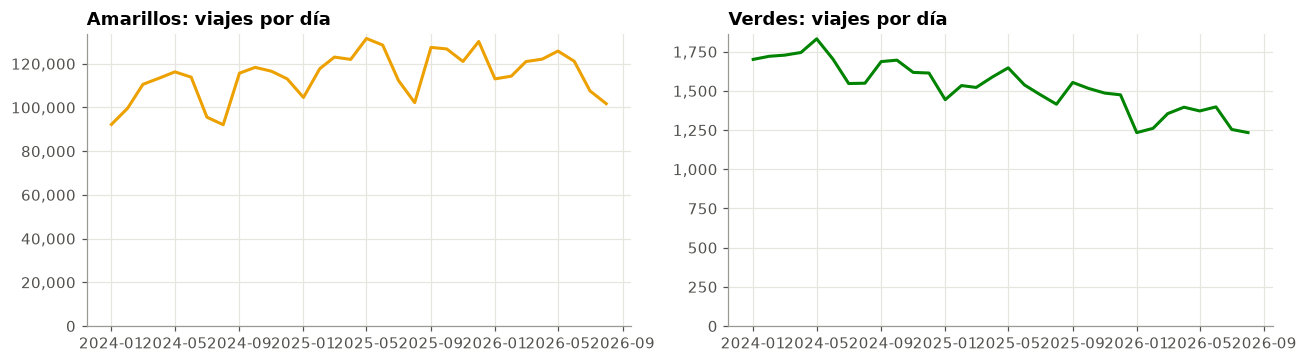

In [6]:
i1 = ejecutar(con, q, "i1_viajes_por_dia")
fig, ejes = plt.subplots(1, 2, figsize=(12, 3.4))
for eje, tipo in zip(ejes, ["yellow", "green"]):
    parte = i1[i1.tipo_taxi == tipo]
    eje.plot(parte.mes, parte.viajes_por_dia, color=COLORES[tipo])
    eje.set_title(f"{NOMBRES[tipo]}: viajes por día")
    eje.set_ylim(bottom=0)
    miles(eje)
plt.tight_layout()
i1["anio"] = i1.mes.dt.year
i1[i1.mes.dt.month <= 8].groupby(["tipo_taxi", "anio"]).viajes_por_dia.mean().round(0).unstack()

**Interpretación.** Comparando enero a agosto de cada año, los amarillos subieron de 104,216 viajes por día en 2024 a 117,746 en 2025 (13 % más) y se mantienen en 115,845 en 2026. Los verdes bajan cada año, de 1,691 a 1,521 y luego a 1,313, una caída acumulada de 22 %.

## I2 Participación de taxis verdes

SELECT
    make_date(anio_archivo, mes_archivo, 1) AS mes,
    round(100.0 * count(*) FILTER (WHERE tipo_taxi = 'green') / count(*), 2) AS pct_verdes
FROM viajes_validos
GROUP BY anio_archivo, mes_archivo
ORDER BY mes;



[i2_participacion_verdes] 32 filas en 2.02 s


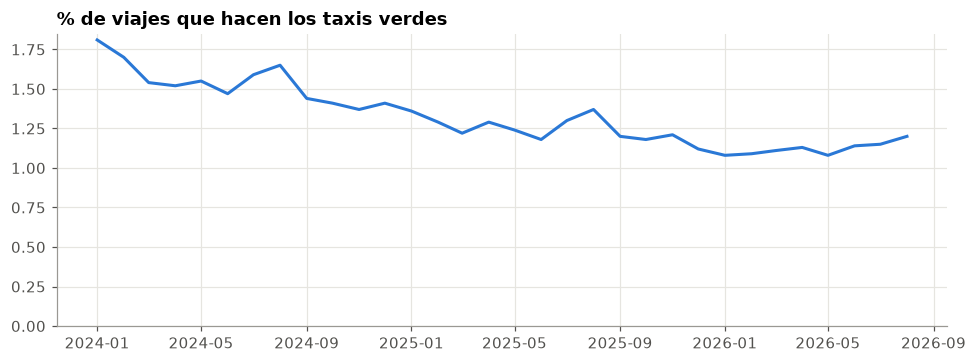

In [7]:
i2 = ejecutar(con, q, "i2_participacion_verdes")
serie(i2, ["pct_verdes"], "% de viajes que hacen los taxis verdes")

**Interpretación.** La participación de los verdes bajó de 1.81 % en enero de 2024 a 1.08 % en enero de 2026. No es solo que crezcan los amarillos, porque los verdes también caen en número absoluto (I1).

## I3 Monto total mediano

SELECT
    make_date(anio_archivo, mes_archivo, 1) AS mes,
    tipo_taxi,
    round(median(total_amount), 2) AS total_mediano_usd,
    round(median(total_amount / trip_distance) FILTER (WHERE trip_distance >= 0.5), 2) AS usd_por_milla
FROM viajes_validos
GROUP BY anio_archivo, mes_archivo, tipo_taxi
ORDER BY mes, tipo_taxi;



[i3_total_mediano] 64 filas en 3.89 s


total_mediano_usd  usd_por_milla
tipo_taxi anio                                  
green     2024              19.15           9.34
          2025              19.87           9.41
          2026              20.58           9.34
yellow    2024              20.90          11.12
          2025              21.63          10.97
          2026              23.61          11.51

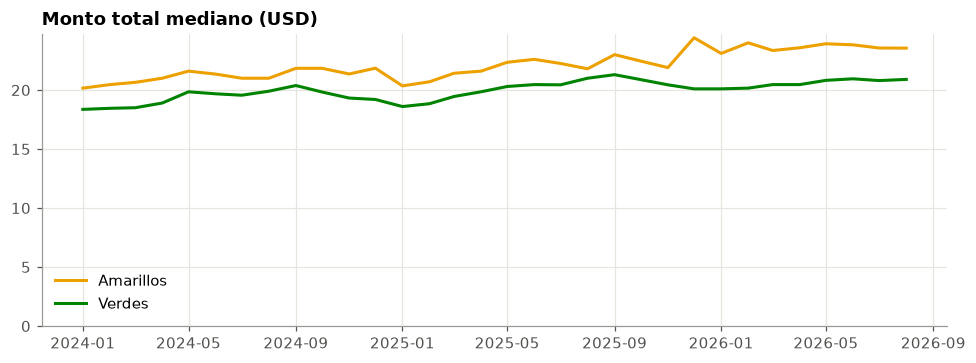

In [8]:
i3 = ejecutar(con, q, "i3_total_mediano")
serie(i3, ["total_mediano_usd"], "Monto total mediano (USD)", por_tipo=True)
i3["anio"] = i3.mes.dt.year
i3[i3.mes.dt.month <= 8].groupby(["tipo_taxi", "anio"])[["total_mediano_usd", "usd_por_milla"]].mean().round(2)

**Interpretación.** Un viaje amarillo típico pasó de 20.90 a 23.61 dólares entre 2024 y 2026 (13 % más, enero a agosto), pero el costo por milla casi no cambió (11.12 contra 11.51). El aumento viene de los recargos y de viajes algo más largos, no de la tarifa por distancia.

## I4 Composición del cobro

In [9]:
ejecutar(con, q, "i4_peso_de_recargos")

SELECT
    anio_archivo::VARCHAR AS anio,
    tipo_taxi,
    round(100 * sum(fare_amount) / sum(total_amount), 1) AS pct_tarifa,
    round(100 * sum(tip_amount) / sum(total_amount), 1) AS pct_propina,
    round(100 * sum(tolls_amount) / sum(total_amount), 1) AS pct_peajes,
    round(100 * sum(coalesce(congestion_surcharge, 0) + coalesce(cbd_congestion_fee, 0)) / sum(total_amount), 1) AS pct_congestion,
    round(100 * sum(coalesce(airport_fee, 0) + extra + mta_tax + improvement_surcharge) / sum(total_amount), 1) AS pct_otros_recargos
FROM viajes_validos
GROUP BY anio_archivo, tipo_taxi
ORDER BY anio, tipo_taxi;



[i4_peso_de_recargos] 6 filas en 2.77 s


,anio,tipo_taxi,pct_tarifa,pct_propina,pct_peajes,pct_congestion,pct_otros_recargos
0,2024,green,74.7,11.0,0.9,3.4,10.5
1,2024,yellow,69.1,11.8,2.0,7.4,10.7
2,2025,green,71.0,10.8,1.1,3.7,9.8
3,2025,yellow,69.4,10.5,1.9,8.2,10.0
4,2026,green,65.7,10.3,1.2,3.4,9.1
5,2026,yellow,70.3,9.5,1.8,7.4,9.2


**Interpretación.** En amarillos la congestión (recargo estatal más cargo CBD) pasa de 7.4 % del cobro en 2024 a 8.2 % en 2025, el año en que empezó el cargo CBD. En 2026 vuelve a 7.4 % porque crecen los registros sin dato del taxímetro, que traen `congestion_surcharge` nulo (ver I6). La propina pierde peso, de 11.8 % a 9.5 %.

## I5 Propina con tarjeta

SELECT
    make_date(anio_archivo, mes_archivo, 1) AS mes,
    tipo_taxi,
    round(median(100 * tip_amount / fare_amount), 1) AS propina_mediana_pct
FROM viajes_validos
WHERE payment_type = 1 AND fare_amount > 0
GROUP BY anio_archivo, mes_archivo, tipo_taxi
ORDER BY mes, tipo_taxi;



[i5_propina_tarjeta] 64 filas en 2.26 s


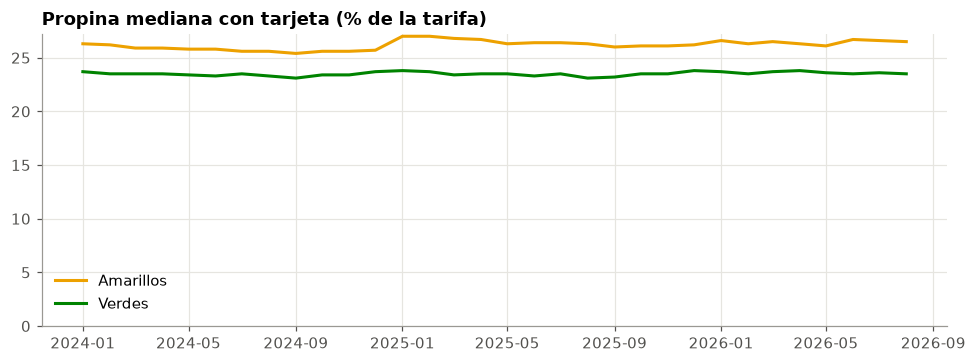

In [10]:
i5 = ejecutar(con, q, "i5_propina_tarjeta")
serie(i5, ["propina_mediana_pct"], "Propina mediana con tarjeta (% de la tarifa)", por_tipo=True)

**Interpretación.** La propina mediana es muy estable, alrededor de 26 % en amarillos y 23.5 % en verdes durante los tres años. La caída del peso de la propina en I4 se explica por el crecimiento de pagos sin dato, no por pasajeros más tacaños.

## I6 Forma de pago

SELECT
    make_date(anio_archivo, mes_archivo, 1) AS mes,
    round(100.0 * count(*) FILTER (WHERE payment_type = 1) / count(*), 1) AS pct_tarjeta,
    round(100.0 * count(*) FILTER (WHERE payment_type = 2) / count(*), 1) AS pct_efectivo,
    round(100.0 * count(*) FILTER (WHERE coalesce(payment_type, 0) = 0) / count(*), 1) AS pct_sin_dato
FROM viajes_validos
WHERE tipo_taxi = 'yellow'
GROUP BY anio_archivo, mes_archivo
ORDER BY mes;



[i6_forma_de_pago] 32 filas en 2.78 s


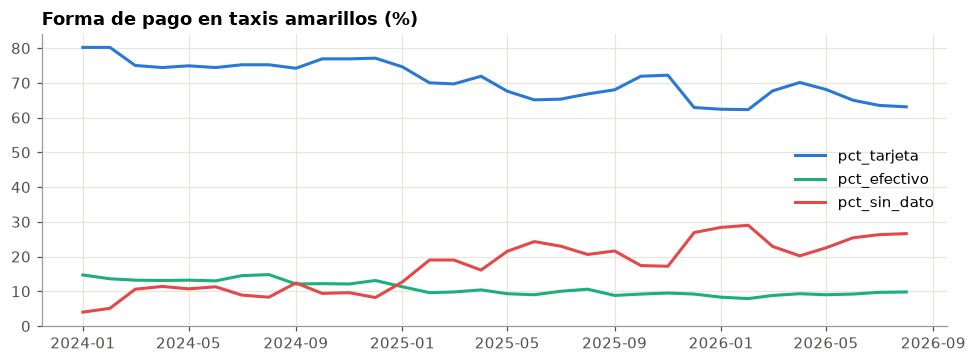

In [11]:
i6 = ejecutar(con, q, "i6_forma_de_pago")
serie(i6, ["pct_tarjeta", "pct_efectivo", "pct_sin_dato"], "Forma de pago en taxis amarillos (%)")

**Interpretación.** Los viajes amarillos sin forma de pago pasan de 4.0 % en enero de 2024 a 29.0 % en febrero de 2026. En el promedio de enero a agosto son 8.79 %, 19.52 % y 25.16 % para cada año. La tarjeta baja de 76.19 % a 65.28 % y el efectivo de 13.76 % a 9.00 %. Es el cambio más grande del periodo y afecta a todos los indicadores que dependen del pago.

## I7 Velocidad en Manhattan

-- Solo viajes que inician y terminan en Manhattan entre semana de 7 a 19 h, para aislar el trafico del centro
SELECT
    make_date(v.anio_archivo, v.mes_archivo, 1) AS mes,
    round(median(v.trip_distance / (v.duracion_min / 60)), 2) AS velocidad_mediana_mph
FROM viajes_validos v
JOIN zonas o ON o.location_id = v.PULocationID
JOIN zonas d ON d.location_id = v.DOLocationID
WHERE o.distrito = 'Manhattan' AND d.distrito = 'Manhattan'
  AND isodow(v.inicio) <= 5 AND hour(v.inicio) BETWEEN 7 AND 18
GROUP BY v.anio_archivo, v.mes_archivo
ORDER BY mes;



[i7_velocidad_manhattan] 32 filas en 3.19 s


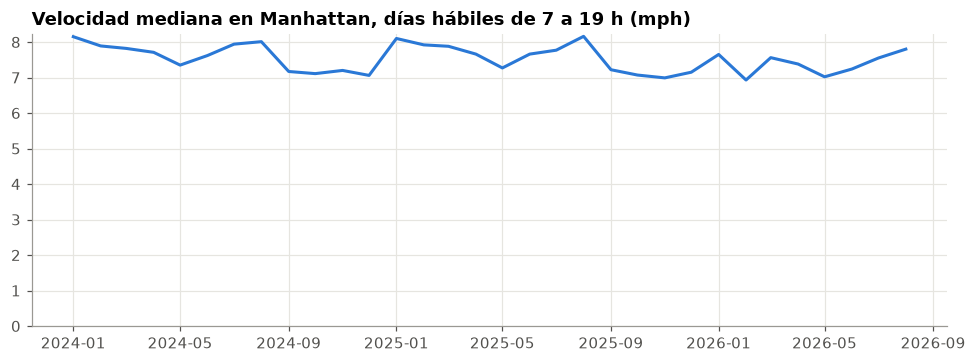

In [12]:
i7 = ejecutar(con, q, "i7_velocidad_manhattan")
serie(i7, ["velocidad_mediana_mph"], "Velocidad mediana en Manhattan, días hábiles de 7 a 19 h (mph)")

**Interpretación.** No se ve una mejora. La velocidad mediana fue 7.81 mph de enero a agosto de 2024, 7.80 en 2025 y 7.39 en 2026. Los meses se repiten casi igual cada año (más lento en mayo y en otoño), así que el patrón estacional pesa más que el cargo por congestión. Es una aproximación, porque la velocidad incluye el tiempo de espera en semáforos y el viaje puede salir del área del cargo.

## I8 Aeropuertos

In [13]:
ejecutar(con, q, "i8_viajes_aeropuerto")

SELECT
    anio_archivo::VARCHAR AS anio,
    round(100.0 * count(*) FILTER (WHERE z.service_zone IN ('Airports', 'EWR')) / count(*), 2) AS pct_desde_aeropuerto,
    round(median(total_amount) FILTER (WHERE z.service_zone IN ('Airports', 'EWR')), 2) AS total_mediano_aeropuerto
FROM viajes_validos v
JOIN zonas z ON z.location_id = v.PULocationID
WHERE tipo_taxi = 'yellow'
GROUP BY anio_archivo
ORDER BY anio;



[i8_viajes_aeropuerto] 3 filas en 2.37 s


,anio,pct_desde_aeropuerto,total_mediano_aeropuerto
0,2024,7.85,78.29
1,2025,6.98,77.94
2,2026,6.48,76.75


**Interpretación.** Los viajes amarillos que inician en un aeropuerto bajan de 7.85 % en 2024 a 6.48 % en 2026, con un monto mediano estable cerca de 77 dólares. JFK y LaGuardia siguen entre las diez zonas principales (I10).

## I9 Distribución por hora

SELECT
    anio_archivo::VARCHAR AS anio,
    hour(inicio) AS hora,
    round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY anio_archivo), 2) AS pct_viajes
FROM viajes_validos
GROUP BY anio_archivo, hora
ORDER BY anio, hora;



[i9_viajes_por_hora] 72 filas en 2.40 s


noche,False,True
anio,,
2024,82.55,17.45
2025,81.17,18.86
2026,80.43,19.56


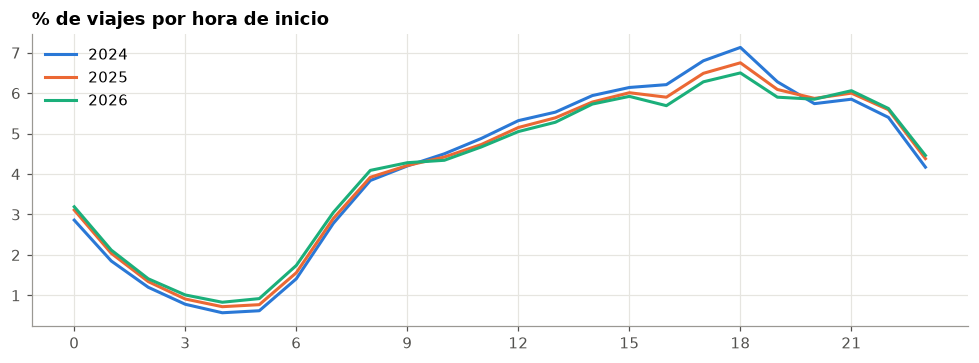

In [14]:
i9 = ejecutar(con, q, "i9_viajes_por_hora")
fig, eje = plt.subplots(figsize=(9, 3.4))
for anio in sorted(i9.anio.unique()):
    parte = i9[i9.anio == anio]
    eje.plot(parte.hora, parte.pct_viajes, color=COLORES[int(anio)], label=anio)
eje.set_title("% de viajes por hora de inicio")
eje.set_xticks(range(0, 24, 3))
eje.legend()
plt.tight_layout()
i9.assign(noche=i9.hora.isin([22, 23, 0, 1, 2, 3, 4, 5])).groupby(["anio", "noche"]).pct_viajes.sum().unstack()

**Interpretación.** El pico sigue a las 18 h, pero los viajes se corren hacia la noche. Entre las 22 y las 5 h se hace el 17.45 % de los viajes de 2024, el 18.86 % de 2025 y el 19.56 % de 2026. A la vez el pico de la tarde se aplana (7.13 % a las 18 h en 2024 contra 6.50 % en 2026).

## I10 Zonas con más recogidas

SELECT
    z.zona || ' (' || z.distrito || ')' AS zona,
    count(*) FILTER (WHERE anio_archivo = (SELECT max(anio_archivo) FROM viajes_validos)) AS viajes_ultimo_anio,
    count(*) AS viajes_total
FROM viajes_validos v
JOIN zonas z ON z.location_id = v.PULocationID
GROUP BY z.zona, z.distrito
ORDER BY viajes_total DESC
LIMIT 10;



[i10_top_zonas] 10 filas en 5.41 s


,zona,viajes_ultimo_anio,viajes_total
0,Upper East Side South (Manhattan),1250881,5113333
1,Midtown Center (Manhattan),1169822,4969574
2,JFK Airport (Queens),1111511,4816454
3,Upper East Side North (Manhattan),1113199,4551627
4,Midtown East (Manhattan),863330,3651353
5,Penn Station/Madison Sq West (Manhattan),867480,3631162
6,Times Sq/Theatre District (Manhattan),815628,3539295
7,Lincoln Square East (Manhattan),810677,3373564
8,LaGuardia Airport (Queens),712362,3187472
9,Murray Hill (Manhattan),736439,3056296


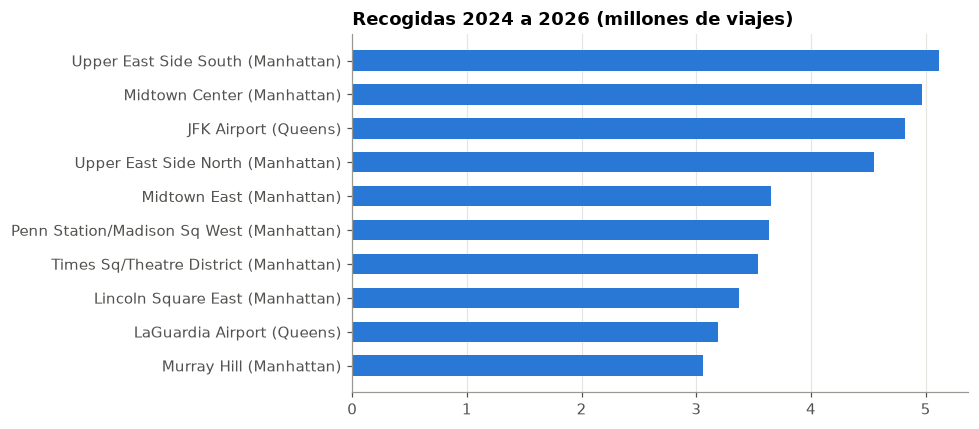

In [15]:
i10 = ejecutar(con, q, "i10_top_zonas")
fig, eje = plt.subplots(figsize=(9, 4))
eje.barh(i10.zona[::-1], i10.viajes_total[::-1] / 1e6, color="#2a78d6", height=0.6)
eje.set_title("Recogidas 2024 a 2026 (millones de viajes)")
eje.grid(axis="y", visible=False)
plt.tight_layout()
i10

**Interpretación.** Upper East Side South, Midtown Center y JFK encabezan la lista con unos 5 millones de recogidas cada una en el periodo. Ocho de las diez zonas están en Manhattan y las otras dos son aeropuertos.

## I11 Registros válidos

-- Se lee de viajes (sin filtrar) porque mide justamente cuanto elimina el filtro
SELECT
    make_date(anio_archivo, mes_archivo, 1) AS mes,
    tipo_taxi,
    round(100.0 * count(*) FILTER (WHERE year(inicio) = anio_archivo AND month(inicio) = mes_archivo
                                     AND duracion_min BETWEEN 1 AND 180
                                     AND trip_distance > 0 AND trip_distance <= 100
                                     AND total_amount > 0 AND fare_amount >= 0) / count(*), 2) AS pct_validos
FROM viajes
GROUP BY anio_archivo, mes_archivo, tipo_taxi
ORDER BY mes, tipo_taxi;



[i11_registros_validos] 64 filas en 1.78 s


mean    min
mes  tipo_taxi              
2024 green      93.02  92.50
     yellow     96.10  95.54
2025 green      93.59  91.45
     yellow     90.41  86.84
2026 green      94.62  94.02
     yellow     94.73  94.11

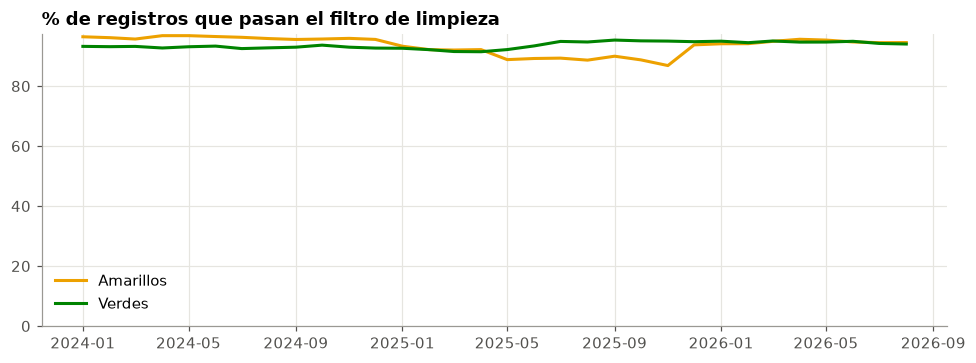

In [16]:
i11 = ejecutar(con, q, "i11_registros_validos")
serie(i11, ["pct_validos"], "% de registros que pasan el filtro de limpieza", por_tipo=True)
i11.groupby([i11.mes.dt.year, "tipo_taxi"]).pct_validos.agg(["mean", "min"]).round(2)

**Interpretación.** La calidad es estable salvo en los amarillos de 2025, cuando el porcentaje válido baja a un promedio de 90.41 % y a un mínimo de 86.84 %. Los indicadores de 2025 se calcularon igual, pero sobre una base algo más filtrada.

## 7.5 Tablero

El tablero de Metabase reúne once indicadores y cuatro valores destacados de 2026. Se genera con `scripts/tablero_metabase.py`, que crea la conexión de solo lectura a `taxis.duckdb`, una pregunta SQL por indicador y el tablero. La captura está en `docs/tablero/tablero_metabase.png`.

![Tablero de Metabase](../docs/tablero/tablero_metabase.png)

## 7.8, 8.5 y 8.6 Hallazgos y cambios entre 2024, 2025 y 2026

**El dato de pago se está perdiendo.** Los viajes amarillos sin forma de pago pasan de 8.79 % a 25.16 % (enero a agosto de cada año). Es el cambio más fuerte del periodo y obliga a leer con cuidado cualquier indicador de pago o pasajeros.

**Los verdes pierden terreno cada año.** Bajan 22 % en viajes por día de 2024 a 2026, mientras los amarillos crecen 11 %. Su participación pasa de 1.60 % a 1.12 %.

**El viaje cuesta más, pero no por milla.** El monto mediano amarillo sube 13 % mientras el costo mediano por milla casi no cambia. La diferencia viene de viajes más largos (la distancia mediana pasa de 1.80 a 1.94 millas) y del cargo CBD, que desde 2025 paga el 73 % de los viajes amarillos.

**El cargo por congestión no se nota en la velocidad.** La velocidad mediana en Manhattan en horario laboral queda entre 7.4 y 7.8 mph en los tres años.

**La demanda se corre hacia la noche.** La proporción de viajes entre las 22 y las 5 h sube de 17.45 % a 19.56 %.

**La propina con tarjeta no cambia.** Se mantiene cerca de 26 % en amarillos, lo que confirma que la caída del peso de la propina en el cobro viene de los registros sin dato.